In [3]:
using Pkg
Pkg.add("FiniteDifferences")


    Updating registry at `/opt/julia/registries/General.toml`
   Resolving package versions...
   Installed Richardson ──────── v1.4.2
   Installed FiniteDifferences ─ v0.12.32
    Updating `/opt/julia/environments/v1.9/Project.toml`
  [26cc04aa] + FiniteDifferences v0.12.32
    Updating `/opt/julia/environments/v1.9/Manifest.toml`
  [26cc04aa] + FiniteDifferences v0.12.32
  [708f8203] + Richardson v1.4.2
Precompiling project...
  ✓ Richardson
  ✓ FiniteDifferences
  2 dependencies successfully precompiled in 79 seconds. 503 already precompiled.


Max iterations reached


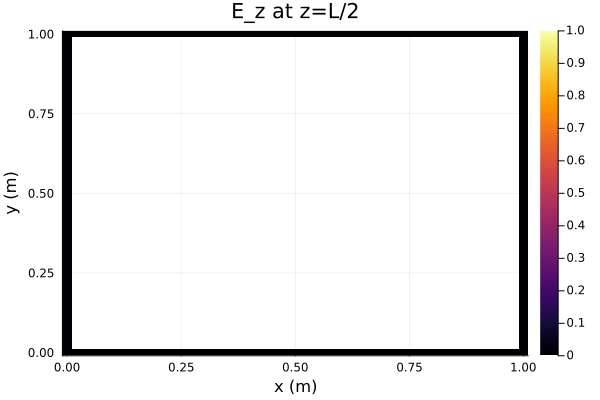

In [5]:
using FiniteDifferences
using LinearAlgebra
using Plots

# 定数
const ϵ₀ = 8.8541878128e-12  # 真空の誘電率 (F/m)

# グリッドの設定
const N = 50  # グリッドの数
const L = 1.0  # 領域の長さ (m)
const Δx = L / (N - 1)  # グリッド間隔
const x = range(0, L, length=N)
const y = range(0, L, length=N)
const z = range(0, L, length=N)

# 電荷密度分布 (例: 中心に点電荷)
ρ = zeros(N, N, N)
ρ[Int(N/2), Int(N/2), Int(N/2)] = 1.0e-9  # 中心に1 nCの点電荷

# 電場の初期化
E_x = zeros(N, N, N)
E_y = zeros(N, N, N)
E_z = zeros(N, N, N)

# ガウスの法則を満たすように電場を計算
function compute_electric_field(ρ, Δx, ϵ₀, max_iter=10000, tol=1e-6)
    N = size(ρ, 1)
    E_x = zeros(N, N, N)
    E_y = zeros(N, N, N)
    E_z = zeros(N, N, N)
    for iter in 1:max_iter
        E_x_old = copy(E_x)
        E_y_old = copy(E_y)
        E_z_old = copy(E_z)
        for i in 2:N-1, j in 2:N-1, k in 2:N-1
            # ガウスの法則を離散化
            div_E = (E_x_old[i+1, j, k] - E_x_old[i-1, j, k]) / (2 * Δx) +
                     (E_y_old[i, j+1, k] - E_y_old[i, j-1, k]) / (2 * Δx) +
                     (E_z_old[i, j, k+1] - E_z_old[i, j, k-1]) / (2 * Δx)
            # 電場を更新
            E_x[i, j, k] += (ρ[i, j, k] / ϵ₀ - div_E) * Δx / 6
            E_y[i, j, k] += (ρ[i, j, k] / ϵ₀ - div_E) * Δx / 6
            E_z[i, j, k] += (ρ[i, j, k] / ϵ₀ - div_E) * Δx / 6
        end
        # 収束判定
        if norm(E_x - E_x_old) + norm(E_y - E_y_old) + norm(E_z - E_z_old) < tol
            println("Converged after $iter iterations")
            return E_x, E_y, E_z
        end
    end
    println("Max iterations reached")
    return E_x, E_y, E_z
end

# 電場を計算
E_x, E_y, E_z = compute_electric_field(ρ, Δx, ϵ₀)

# 結果の可視化 (2Dスライス)
heatmap(x, y, E_x[:, :, Int(N/2)], xlabel="x (m)", ylabel="y (m)", title="E_x at z=L/2")
heatmap(x, y, E_y[:, :, Int(N/2)], xlabel="x (m)", ylabel="y (m)", title="E_y at z=L/2")
heatmap(x, y, E_z[:, :, Int(N/2)], xlabel="x (m)", ylabel="y (m)", title="E_z at z=L/2")